#  Tech Assessment: Weather Trend Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

In [2]:
# read csv
df = pd.read_csv("./data/GlobalWeatherRepository.csv")
print(df.shape)
df.sample(6)

(130003, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
53468,Guinea,Conakry,9.5092,-13.7122,Africa/Conakry,1739700900,2025-02-16 10:15,25.2,77.4,Sunny,...,64.380,152.995,3,8,07:14 AM,07:04 PM,10:13 PM,09:43 AM,Waning Gibbous,89
90959,Senegal,Dakar,14.6708,-17.4381,Africa/Dakar,1756281600,2025-08-27 08:00,28.4,83.1,Partly cloudy,...,44.585,215.340,3,5,06:57 AM,07:25 PM,10:17 AM,10:09 PM,Waxing Crescent,14
9005,Japan,Tokyo,35.6900,139.6900,Asia/Tokyo,1719754200,2024-06-30 22:30,27.0,80.6,Partly cloudy,...,10.600,11.700,1,1,04:28 AM,07:01 PM,No moonrise,01:10 PM,Waning Crescent,38
37267,Bangladesh,Dhaka,23.7231,90.4086,Asia/Dhaka,1732523400,2024-11-25 14:30,27.4,81.2,Sunny,...,308.395,317.830,6,10,06:20 AM,05:11 PM,01:07 AM,01:36 PM,Waning Crescent,34
22307,Azerbaijan,Baku,40.4000,49.8800,Asia/Baku,1725885000,2024-09-09 16:30,27.4,81.3,Sunny,...,22.200,76.960,2,2,06:16 AM,06:59 PM,12:18 PM,09:40 PM,Waxing Crescent,28
3415,Mali,Bamako,12.6500,-8.0000,Africa/Bamako,1717252200,2024-06-01 14:30,41.0,105.8,Sunny,...,28.500,144.400,2,3,06:05 AM,06:55 PM,01:52 AM,02:15 PM,Waning Crescent,35


In [3]:
# display df stats
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,130003.000000,130003.000000,1.300030e+05,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,...,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000
mean,19.203631,21.976354,1.744777e+09,21.404561,70.529999,8.042931,12.947448,168.959509,1014.097521,29.945664,...,18.295989,468.990972,58.452398,15.142142,10.531454,24.463289,48.967420,1.706922,2.625162,49.725629
std,24.420627,65.788604,1.669083e+07,9.688223,17.438649,7.297507,11.741068,103.572696,10.497520,0.309957,...,13.922968,769.933810,30.962557,23.987244,36.312698,37.398961,151.004804,0.946519,2.461476,35.020085
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.870000,-6.836100,1.730365e+09,16.100000,61.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.300000,207.200000,38.000000,1.665000,1.100000,7.150000,10.000000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.744794e+09,24.000000,75.300000,6.900000,11.200000,161.000000,1014.000000,29.930000,...,15.400000,299.700000,55.100000,5.550000,2.405000,14.245000,20.165000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.759219e+09,28.000000,82.400000,11.000000,17.600000,255.000000,1018.000000,30.060000,...,24.300000,467.300000,74.000000,17.575000,8.510000,28.050000,41.950000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.773730e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [4]:
# display all columns
df.columns.values.tolist()

['country',
 'location_name',
 'latitude',
 'longitude',
 'timezone',
 'last_updated_epoch',
 'last_updated',
 'temperature_celsius',
 'temperature_fahrenheit',
 'condition_text',
 'wind_mph',
 'wind_kph',
 'wind_degree',
 'wind_direction',
 'pressure_mb',
 'pressure_in',
 'precip_mm',
 'precip_in',
 'humidity',
 'cloud',
 'feels_like_celsius',
 'feels_like_fahrenheit',
 'visibility_km',
 'visibility_miles',
 'uv_index',
 'gust_mph',
 'gust_kph',
 'air_quality_Carbon_Monoxide',
 'air_quality_Ozone',
 'air_quality_Nitrogen_dioxide',
 'air_quality_Sulphur_dioxide',
 'air_quality_PM2.5',
 'air_quality_PM10',
 'air_quality_us-epa-index',
 'air_quality_gb-defra-index',
 'sunrise',
 'sunset',
 'moonrise',
 'moonset',
 'moon_phase',
 'moon_illumination']

# Basic Assessment

## Data Cleaning & Preprocessing
* Handle missing values
* outliers
* normalize data

### Missing Values

In [5]:
# Handle missing values
missing_count = df.isnull().sum()

print("Missing values per column")
missing_count[missing_count > 0]

# if missing values, either drop rows with them / replace missing values with mean, median or relevant mode / fill missing values with closest values in column / interpolation technique 

Missing values per column


Series([], dtype: int64)

!!! NO MISSING VALUES

### Outliers
* Outliers that may vary - be careful
    * tmp, humidity, pressure, wind, UV, precipitation 
    * condition text, wind direction, air quality indices
* extreme real event vs real outlier

In [6]:
# IQR DOES NOT WORK (24,163 outliers)
# Hard limit based on meteorology like max and min celsius known

domain_limits = {
    'temperature_celsius': (-90, 60),   # record low ~-89.2°C, high ~56.7°C
    'wind_kph':            (0, 408),    # world record ~408 kph
    'pressure_mb':         (870, 1085), # typhoon lows ~870, highs ~1085
    'precip_mm':           (0, 1400),   # daily record ~1825mm
}

df_original = df.copy()  # preserve original for anomaly comparison later

impossible_counts = {}
for col, (lower, upper) in domain_limits.items():
    n_impossible = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    impossible_counts[col] = n_impossible
    df[col] = df[col].clip(lower=lower, upper=upper)
    if n_impossible > 0:
        print(f"{col}: Clipped {n_impossible} physically impossible values.")
    else:
        print(f"{col}: No physically impossible values found.")

print("\nDomain clipping complete. Statistical anomaly detection → Advanced EDA.")


temperature_celsius: No physically impossible values found.
wind_kph: Clipped 1 physically impossible values.
pressure_mb: Clipped 2 physically impossible values.
precip_mm: No physically impossible values found.

Domain clipping complete. Statistical anomaly detection → Advanced EDA.


### Advanced EDA - Outliers

In [7]:
from sklearn.ensemble import IsolationForest
import matplotlib.patches as mpatches

ANOMALY_FEATURES = [
    'temperature_celsius', 'humidity', 'pressure_mb',
    'wind_kph', 'precip_mm', 'uv_index', 'cloud',
    'air_quality_PM2.5', 'air_quality_Carbon_Monoxide'
]

# Work on the full cleaned df (before train/test split and scaling)
# Use df_original domain-clipped values (already stored in df at this point)
anomaly_df = df[['last_updated', 'location_name', 'country', 'latitude', 'longitude'] + ANOMALY_FEATURES].copy()
anomaly_df['last_updated'] = pd.to_datetime(anomaly_df['last_updated'])

print(f"Anomaly detection dataset: {anomaly_df.shape}")

Anomaly detection dataset: (130003, 14)


In [8]:
# ISOLATION FOREST
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

# Fill any NaNs in features with median before fitting
feat_matrix = anomaly_df[ANOMALY_FEATURES].fillna(anomaly_df[ANOMALY_FEATURES].median())

anomaly_df['iso_score'] = iso_forest.fit_predict(feat_matrix)   # -1 = anomaly, 1 = normal
anomaly_df['iso_anomaly'] = (anomaly_df['iso_score'] == -1)
anomaly_df['iso_decision_score'] = iso_forest.decision_function(feat_matrix)  # lower = more anomalous

n_iso = anomaly_df['iso_anomaly'].sum()
print(f"Isolation Forest flagged: {n_iso} anomalies ({n_iso/len(anomaly_df)*100:.2f}% of dataset)")

Isolation Forest flagged: 2601 anomalies (2.00% of dataset)


In [ ]:
# PER-CITY Z-SCORE FLAGGING 
# Flags readings that are extreme - relative to that city's own climate.

Z_THRESHOLD = 3.5

def city_zscore_flag(group, cols, threshold):
    flags = pd.Series(False, index=group.index)
    for col in cols:
        mean = group[col].mean()
        std  = group[col].std()
        if std > 0:
            z = (group[col] - mean) / std
            flags |= z.abs() > threshold
    return flags

city_z_cols = ['temperature_celsius', 'pressure_mb', 'wind_kph', 'precip_mm']

anomaly_df['city_z_anomaly'] = (
    anomaly_df.groupby('location_name', group_keys=False)
    .apply(lambda g: city_zscore_flag(g, city_z_cols, Z_THRESHOLD))
)

n_city_z = anomaly_df['city_z_anomaly'].sum()
print(f"Per-city Z-score flagged: {n_city_z} anomalies ({n_city_z/len(anomaly_df)*100:.2f}%)")

# caught by BOTH methods for high-confidence
anomaly_df['both_methods'] = anomaly_df['iso_anomaly'] & anomaly_df['city_z_anomaly']
n_both = anomaly_df['both_methods'].sum()
print(f"Flagged by BOTH methods:  {n_both} anomalies ({n_both/len(anomaly_df)*100:.2f}%) ← high-confidence")

Per-city Z-score flagged: 2365 anomalies (1.82%)
Flagged by BOTH methods:  568 anomalies (0.44%) ← high-confidence


/var/folders/g6/f1gwjy8559q53gsjmv0zgf0m0000gn/T/ipykernel_12727/2069533147.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: city_zscore_flag(g, city_z_cols, Z_THRESHOLD))


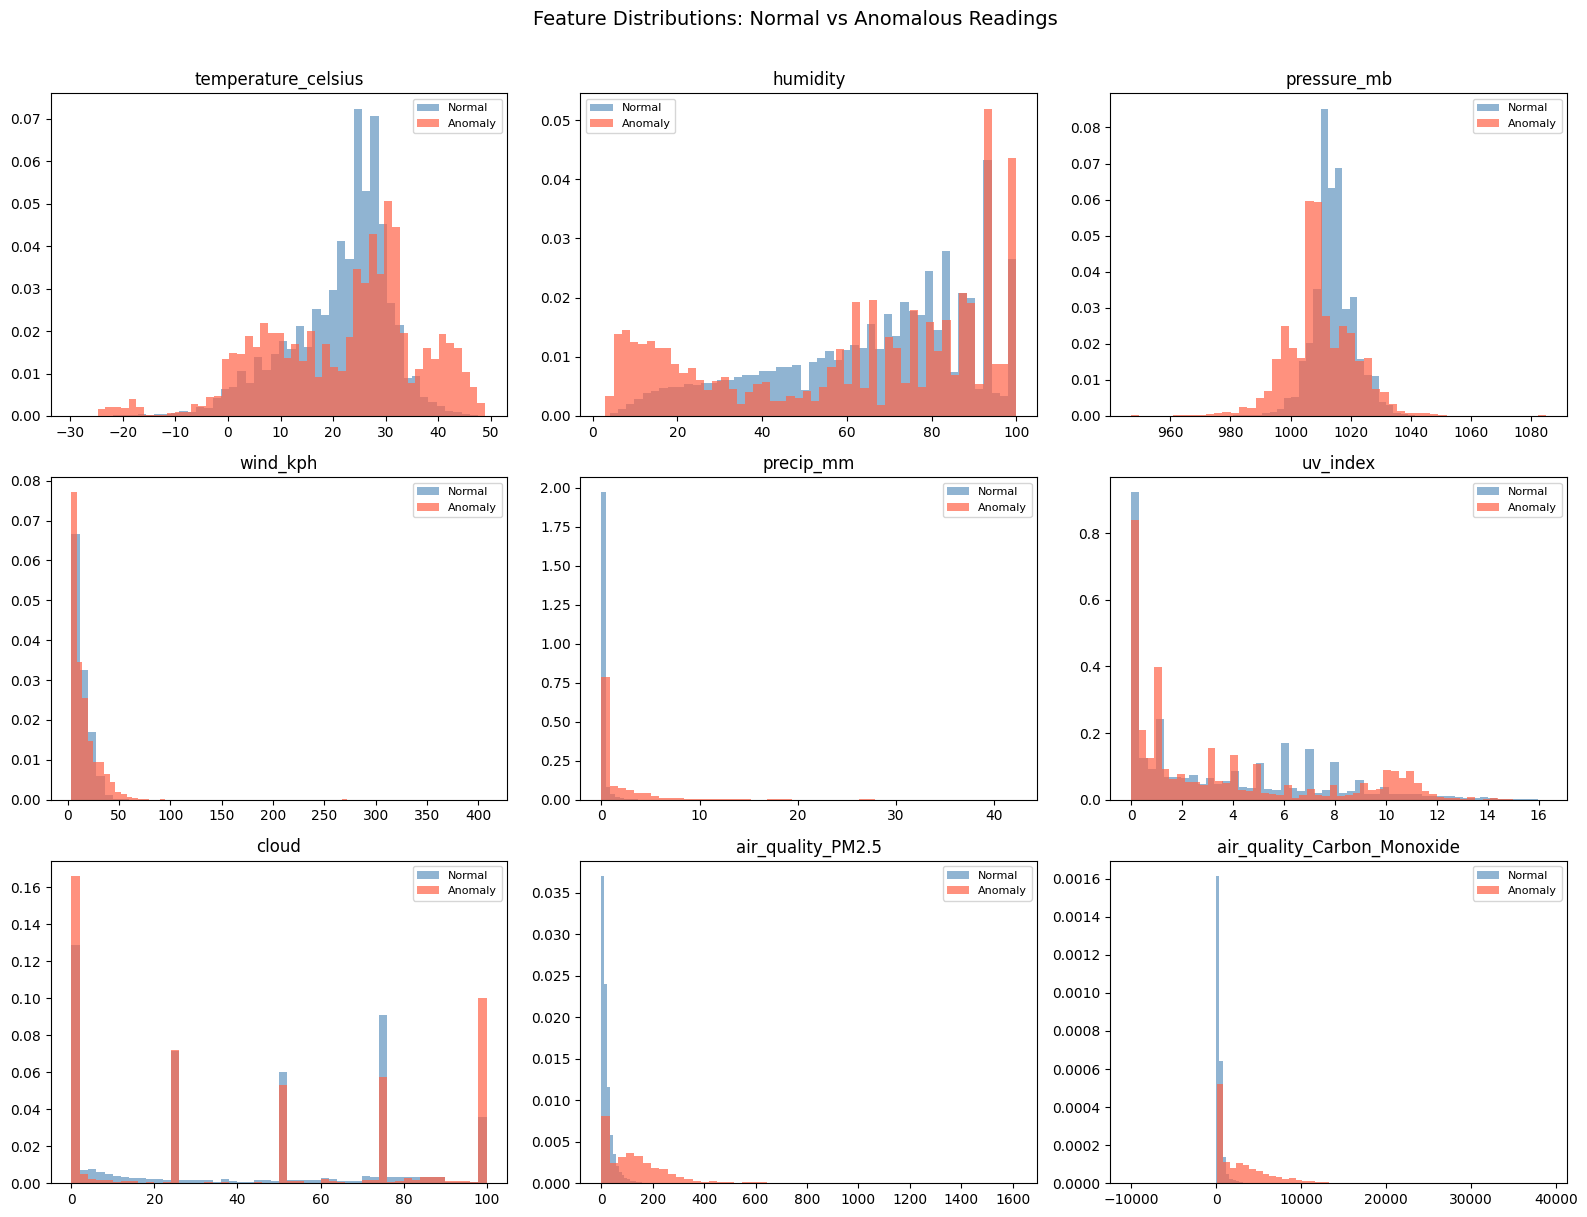

In [31]:
# ANOMALIES ACROSS FEATURES


normal   = anomaly_df[~anomaly_df['iso_anomaly']]
anomalies = anomaly_df[anomaly_df['iso_anomaly']]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(ANOMALY_FEATURES):
    axes[i].hist(normal[col].dropna(), bins=50, color='steelblue',
                 alpha=0.6, label='Normal', density=True)
    axes[i].hist(anomalies[col].dropna(), bins=50, color='tomato',
                 alpha=0.7, label='Anomaly', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Normal vs Anomalous Readings', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# SUMMARY TABLE: High-confidence anomalies (both methods) 

high_conf = anomaly_df[anomaly_df['both_methods']].copy()
high_conf_display = (
    high_conf[['last_updated', 'country', 'location_name'] + ANOMALY_FEATURES + ['iso_decision_score']]
    .sort_values('iso_decision_score')   # most extreme first
    .head(20)
)

print(f"\nTop 20 most extreme anomalies (flagged by both methods):")
print(high_conf_display.to_string(index=False))


Top 20 most extreme anomalies (flagged by both methods):
       last_updated     country  location_name  temperature_celsius  humidity  pressure_mb  wind_kph  precip_mm  uv_index  cloud  air_quality_PM2.5  air_quality_Carbon_Monoxide  iso_decision_score
2024-06-13 10:00:00       Chile       Santiago                 11.2        94       1010.0       9.0       4.41       3.0    100            338.500                     5607.600           -0.168384
2024-05-22 21:15:00   Indonesia        Jakarta                 29.0        79       1009.0      15.1       2.49       1.0     50            384.800                    18585.199           -0.140638
2024-09-07 19:00:00     Vietnam          Hanoi                 26.2        89        985.0      56.2      27.82       1.0    100              9.435                      562.400           -0.130616
2024-05-22 10:15:00       Chile       Santiago                 10.0        94       1015.0      11.2       0.96       4.0    100            579.300       

In [11]:
# check stats
stats_check = []
for col in ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm']:
    mean = df[col].mean()
    std = df[col].std()
    stats_check.append({
        'Feature': col,
        'Mean': round(mean, 2),
        'Std Dev': round(std, 2),
        'Lower Bound (Mean - 3σ)': round(mean - 3*std, 2),
        'Upper Bound (Mean + 3σ)': round(mean + 3*std, 2),
        'Max Value': df[col].max()
    })

pd.DataFrame(stats_check)

,Feature,Mean,Std Dev,Lower Bound (Mean - 3σ),Upper Bound (Mean + 3σ),Max Value
0,temperature_celsius,21.40,9.69,-7.66,50.47,49.20
1,wind_kph,12.93,8.49,-12.55,38.40,408.00
2,pressure_mb,1014.07,7.03,992.98,1035.16,1085.00
3,precip_mm,0.14,0.56,-1.56,1.83,42.24


### Normalize Data
* differente scales for data
* XGBoost + LSTM? + Sarimax for seasonality
* XGBoost - NO normalization need (tree based)
* LSTM/SARIMAX - Standard Z-score normalization 

In [12]:
# time sorting
df = df.sort_values('last_updated')

# data split 80 / 20
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# feat to scale
cols_to_scale = ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity']

# log transform precip_mm before scaling (too skewed)
train_df['precip_mm'] = np.log1p(train_df['precip_mm'])
test_df['precip_mm'] = np.log1p(test_df['precip_mm'])

# fit on train, transform on both
scaler = StandardScaler()
train_df[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])
test_df[cols_to_scale] = scaler.transform(test_df[cols_to_scale])

print(f"Split complete. Train set: {train_df.shape[0]} rows | Test set: {test_df.shape[0]} rows")

Split complete. Train set: 104002 rows | Test set: 26001 rows


## Exploratory Data Analysis (EDA)

### Perform basic EDA to uncover the trends, correlations, and patterns.
* feature relationship
* autocorr (ACF) and partial autocorr (PACF)
* spearman heatmap - non linear relation -
* decompose target var into its trend
* Plotting rolling means/standard deviations and performing the Augmented Dickey-Fuller (ADF) test - SARIMAX requires data to be stationary

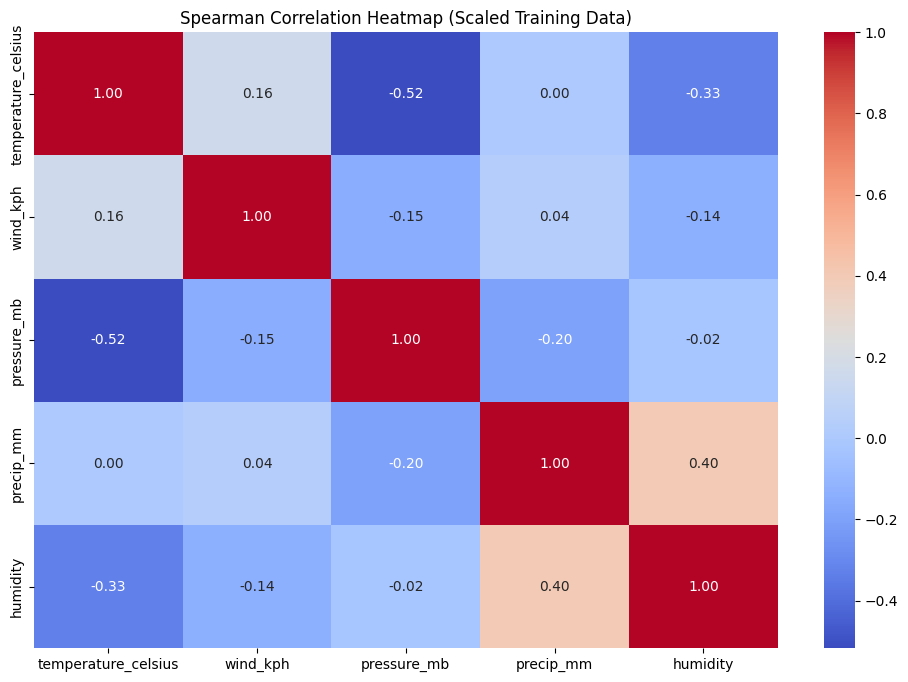

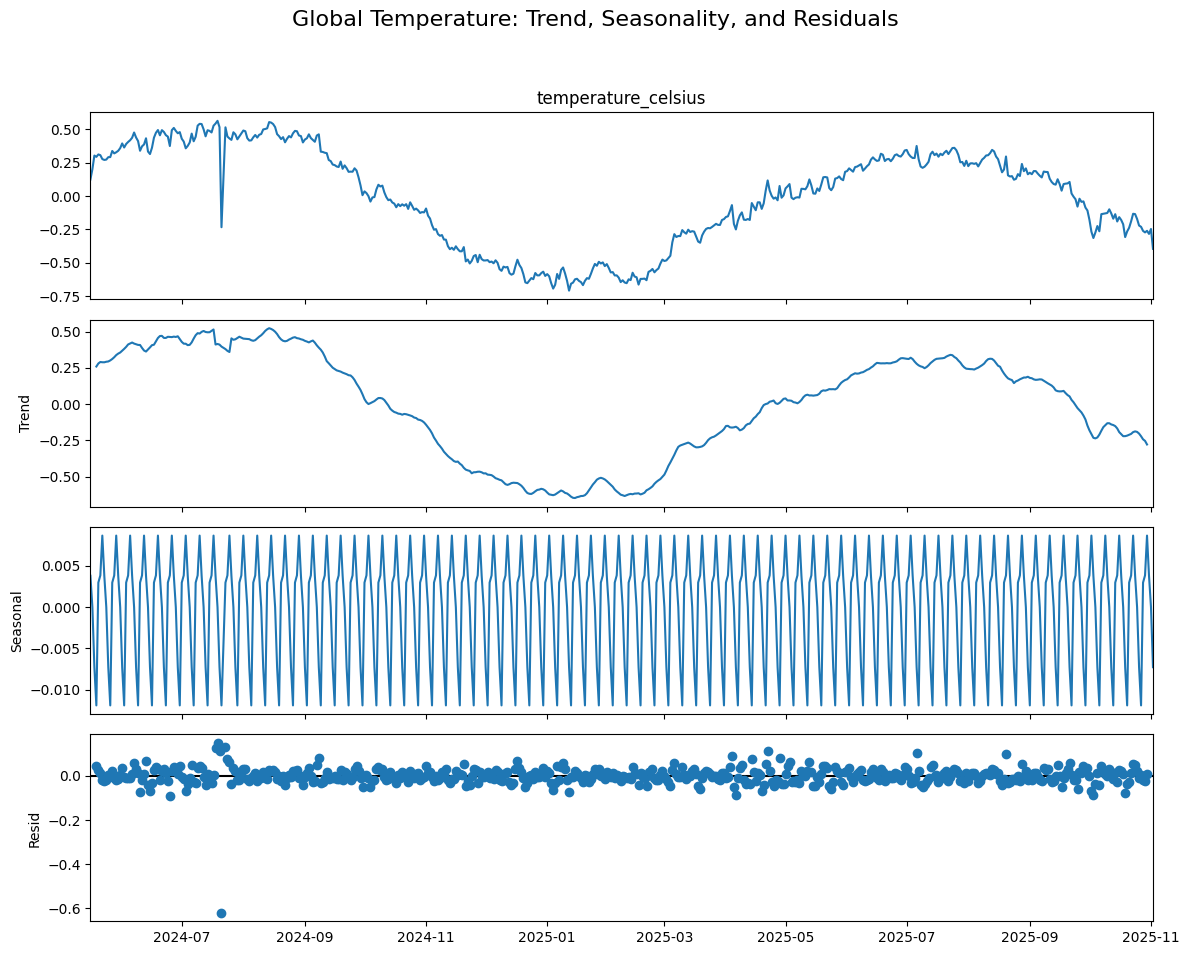

In [13]:

# Heatmap for Feature Relationships
plt.figure(figsize=(12, 8))
# spearman relation since weather relations are not linear
correlation_matrix = train_df[cols_to_scale].corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap (Scaled Training Data)")
plt.show()

# ensure column is datetime
train_df['last_updated'] = pd.to_datetime(train_df['last_updated'])

# set index and cast to DatetimeIndex (prevent pandas indexing error)
temp_series = train_df.set_index('last_updated')['temperature_celsius']
temp_series.index = pd.DatetimeIndex(temp_series.index)

# resample to daily mean and drop nans it could create
daily_temp = temp_series.resample('D').mean().dropna()

# Seasonal Decomposition
# typically weekly or yearly seasonality for weather
# stick with 7 for a short-term trend.


decomposition = seasonal_decompose(daily_temp, model='additive', period=7)

# plot
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Global Temperature: Trend, Seasonality, and Residuals', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

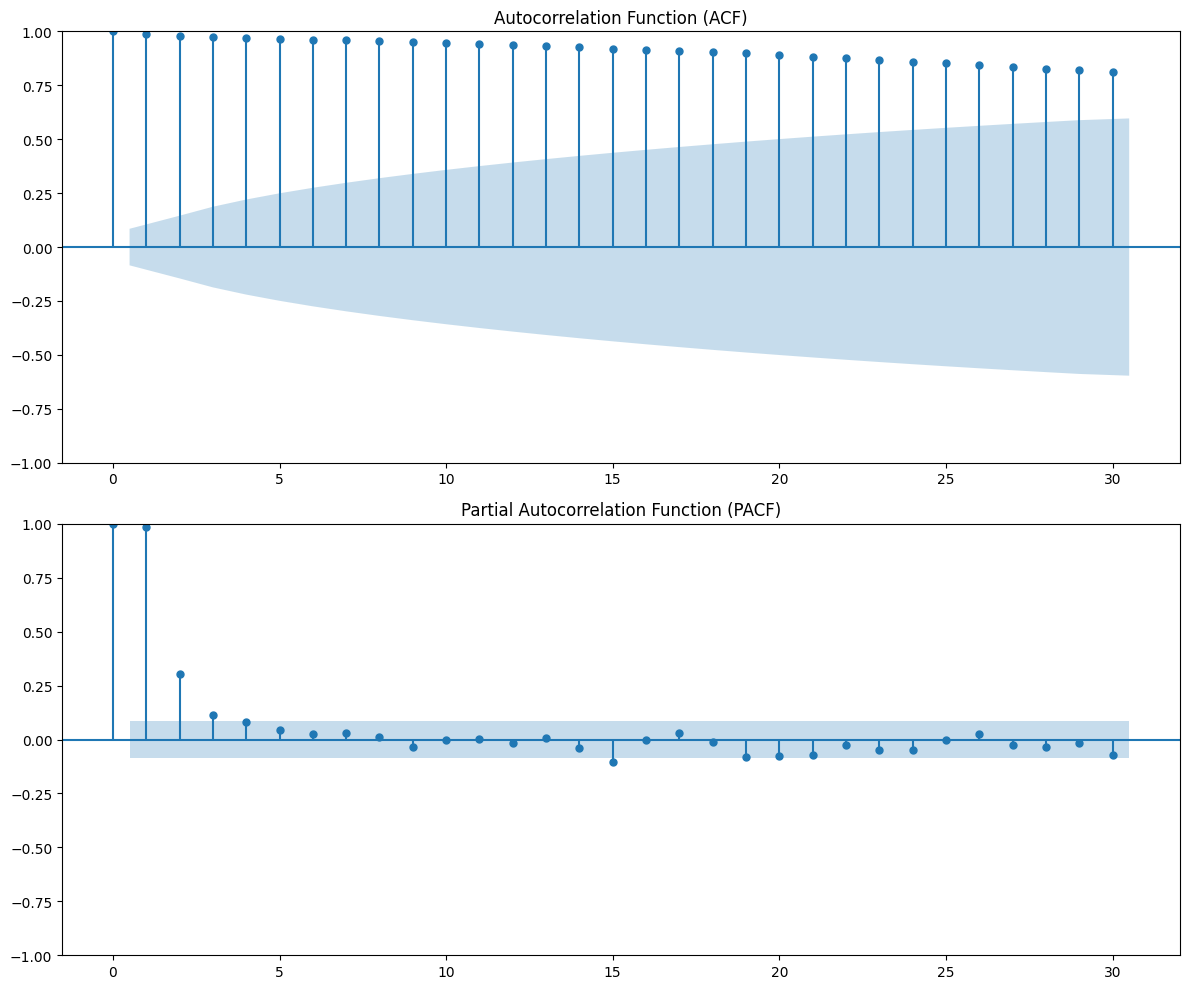

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF
plot_acf(daily_temp, lags=30, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# PACF
plot_pacf(daily_temp, lags=30, ax=ax2, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

* Strong trend in the data
* todays weahter high correlated with yestearday, before, and so on
* Suggests Auto-Regressive (AR) process
* Almost all predictive power comes from the 1-2 days

### Visualization for temperature and precipitation
* boxplot of temp/precipitaion by continent or region

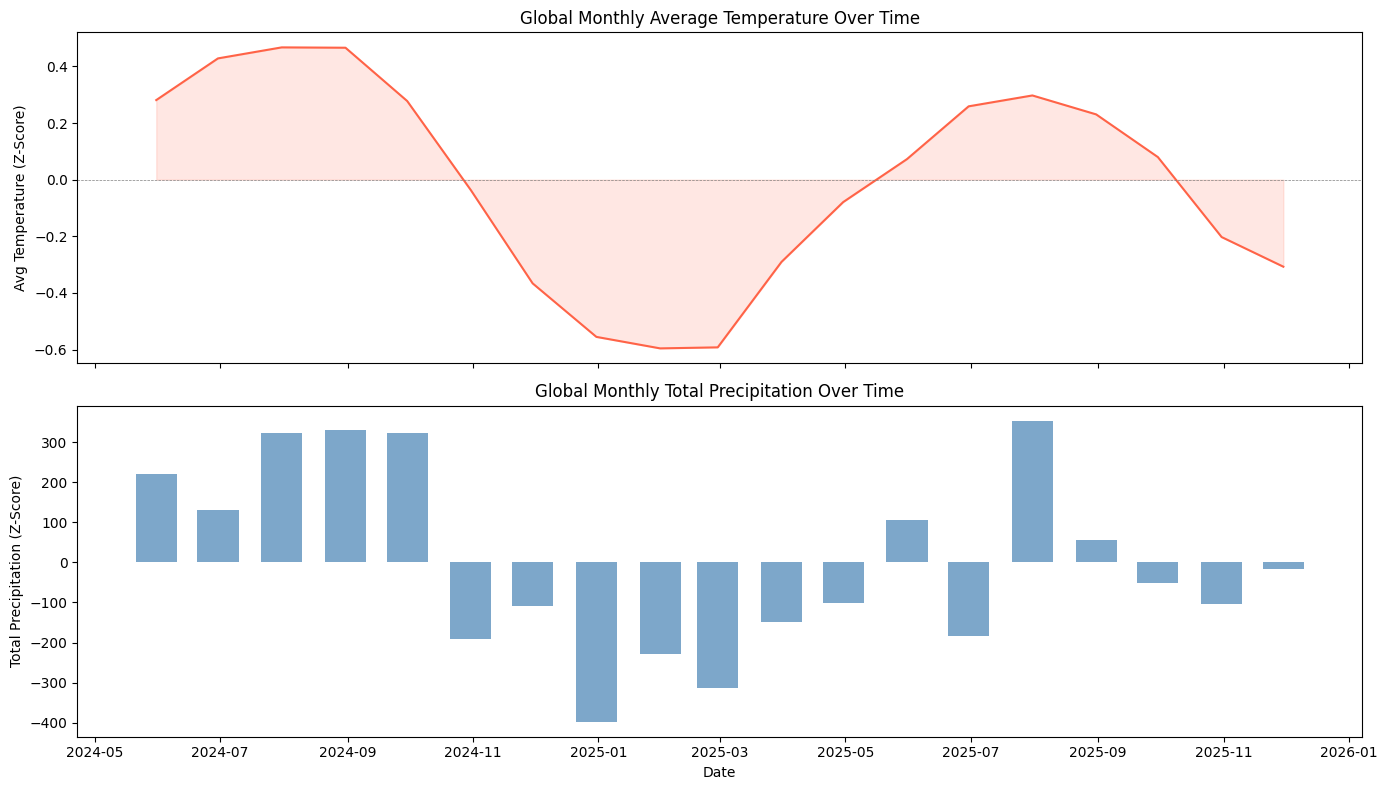

In [15]:
# temperature: monthly mean over time 
train_df['last_updated'] = pd.to_datetime(train_df['last_updated'])
monthly = train_df.set_index('last_updated').resample('ME').agg(
    temp_mean=('temperature_celsius', 'mean'),
    precip_sum=('precip_mm', 'sum')
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# temp trend
ax1.plot(monthly['last_updated'], monthly['temp_mean'], color='tomato', linewidth=1.5)
ax1.fill_between(monthly['last_updated'], monthly['temp_mean'], alpha=0.15, color='tomato')
ax1.set_ylabel('Avg Temperature (Z-Score)')
ax1.set_title('Global Monthly Average Temperature Over Time')
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# precip trend
ax2.bar(monthly['last_updated'], monthly['precip_sum'], color='steelblue',
        width=20, alpha=0.7)
ax2.set_ylabel('Total Precipitation (Z-Score)')
ax2.set_title('Global Monthly Total Precipitation Over Time')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

## Model Building

### Build a basic forecasting model and evaluate its performance using different metrics.
* Final planned model: XGBoost + LightGBM + LSTM
    * START with __XGBoost__

* target var: temperature_celsius? maybe not accurate for capturing TREND
    * use other target var or create
* target is scaled (z-scored). INVERSE it to better human interpretability 

In [16]:
warnings.filterwarnings('ignore')
# FEATURE ENGINNERING

def engineer_features(df_input):
    df_feat = df_input.copy()
    df_feat['last_updated'] = pd.to_datetime(df_feat['last_updated'])

    # cyclical time encodings (preserve periodicity) 
    df_feat['hour']       = df_feat['last_updated'].dt.hour
    df_feat['dayofyear']  = df_feat['last_updated'].dt.dayofyear
    df_feat['month']      = df_feat['last_updated'].dt.month

    df_feat['hour_sin']      = np.sin(2 * np.pi * df_feat['hour'] / 24)
    df_feat['hour_cos']      = np.cos(2 * np.pi * df_feat['hour'] / 24)
    df_feat['doy_sin']       = np.sin(2 * np.pi * df_feat['dayofyear'] / 365)
    df_feat['doy_cos']       = np.cos(2 * np.pi * df_feat['dayofyear'] / 365)
    df_feat['month_sin']     = np.sin(2 * np.pi * df_feat['month'] / 12)
    df_feat['month_cos']     = np.cos(2 * np.pi * df_feat['month'] / 12)

    # lag feats - per city to avoid leakage across locations
    df_feat = df_feat.sort_values(['location_name', 'last_updated'])
    for lag in [1, 2, 3, 6, 12, 24]:
        df_feat[f'temp_lag_{lag}'] = (
            df_feat.groupby('location_name')['temperature_celsius'].shift(lag)
        )

    # rolling statistics (per city) 
    for window in [6, 24]:
        df_feat[f'temp_roll_mean_{window}'] = (
            df_feat.groupby('location_name')['temperature_celsius']
            .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
        )
        df_feat[f'temp_roll_std_{window}'] = (
            df_feat.groupby('location_name')['temperature_celsius']
            .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
        )

    return df_feat


train_feat = engineer_features(train_df)
test_feat  = engineer_features(test_df)

# Drop rows where lag features are NaN (first observations per city)
train_feat = train_feat.dropna(subset=[c for c in train_feat.columns if 'lag' in c or 'roll' in c])
test_feat  = test_feat.dropna(subset=[c for c in test_feat.columns if 'lag' in c or 'roll' in c])

print(f"Train after feature engineering: {train_feat.shape}")
print(f"Test  after feature engineering: {test_feat.shape}")

Train after feature engineering: (98758, 60)
Test  after feature engineering: (21236, 60)


In [17]:
# FEATURES SET

FEATURE_COLS = [
    # meteorological features (already scaled)
    'humidity', 'pressure_mb', 'wind_kph', 'precip_mm',
    'cloud', 'uv_index', 'visibility_km',
    # spatial context
    'latitude', 'longitude',
    # cyclical time encodings
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos',
    # lag features
    'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_6', 'temp_lag_12', 'temp_lag_24',
    # rolling stats
    'temp_roll_mean_6', 'temp_roll_mean_24',
    'temp_roll_std_6',  'temp_roll_std_24',
]

TARGET = 'temperature_celsius'

X_train = train_feat[FEATURE_COLS]
y_train = train_feat[TARGET]

X_test  = test_feat[FEATURE_COLS]
y_test  = test_feat[TARGET]

print(f"Features: {len(FEATURE_COLS)} | X_train: {X_train.shape} | X_test: {X_test.shape}")

Features: 25 | X_train: (98758, 25) | X_test: (21236, 25)


In [18]:
# CROSS-VALIDATION (TimeSeriesSplit) 
# TimeSeriesSplit respects temporal ordering

tscv = TimeSeriesSplit(n_splits=5)

xgb_params = {
    'n_estimators':     500,
    'learning_rate':    0.05,
    'max_depth':        6,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'reg_alpha':        0.1,    # L1
    'reg_lambda':       1.0,    # L2
    'tree_method':      'hist', # fast histogram method
    'random_state':     42,
    'n_jobs':           -1,
}

cv_maes, cv_rmses, cv_r2s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model_cv = xgb.XGBRegressor(**xgb_params)
    model_cv.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds_val = model_cv.predict(X_val)

    cv_maes.append(mean_absolute_error(y_val, preds_val))
    cv_rmses.append(np.sqrt(mean_squared_error(y_val, preds_val)))
    cv_r2s.append(r2_score(y_val, preds_val))

    print(f"  Fold {fold+1} | MAE: {cv_maes[-1]:.4f} | RMSE: {cv_rmses[-1]:.4f} | R²: {cv_r2s[-1]:.4f}")

print(f"\nCV Summary (scaled units):")
print(f"  MAE  : {np.mean(cv_maes):.4f} ± {np.std(cv_maes):.4f}")
print(f"  RMSE : {np.mean(cv_rmses):.4f} ± {np.std(cv_rmses):.4f}")
print(f"  R²   : {np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}")

  Fold 1 | MAE: 0.1598 | RMSE: 0.2212 | R²: 0.9500
  Fold 2 | MAE: 0.1410 | RMSE: 0.1893 | R²: 0.9523
  Fold 3 | MAE: 0.1664 | RMSE: 0.2318 | R²: 0.9453
  Fold 4 | MAE: 0.1341 | RMSE: 0.1849 | R²: 0.9563
  Fold 5 | MAE: 0.1709 | RMSE: 0.2446 | R²: 0.9546

CV Summary (scaled units):
  MAE  : 0.1545 ± 0.0144
  RMSE : 0.2144 ± 0.0235
  R²   : 0.9517 ± 0.0038


In [19]:
# TRAINING

xgb_final = xgb.XGBRegressor(**xgb_params)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:1.41905
[100]	validation_0-rmse:0.27146
[200]	validation_0-rmse:0.26234
[300]	validation_0-rmse:0.25912
[400]	validation_0-rmse:0.25751
[499]	validation_0-rmse:0.25659


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [20]:
# EVALUATION on test set - invert scale for better read
# scaler was fit on ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity']
# temperature_celsius is index 0 - only invert its column

def inverse_temp(y_scaled):
    """Inverse the StandardScaler for temperature_celsius only (index 0)."""
    dummy = np.zeros((len(y_scaled), len(cols_to_scale)))
    dummy[:, 0] = y_scaled
    return scaler.inverse_transform(dummy)[:, 0]

y_pred_scaled = xgb_final.predict(X_test)
y_pred_celsius = inverse_temp(y_pred_scaled)
y_true_celsius = inverse_temp(y_test.values)

mae  = mean_absolute_error(y_true_celsius, y_pred_celsius)
rmse = np.sqrt(mean_squared_error(y_true_celsius, y_pred_celsius))
r2   = r2_score(y_true_celsius, y_pred_celsius)
from sklearn.metrics import max_error
smape = np.mean(2 * np.abs(y_pred_celsius - y_true_celsius) /
                (np.abs(y_true_celsius) + np.abs(y_pred_celsius) + 1e-8)) * 100
max_err = max_error(y_true_celsius, y_pred_celsius)

print("── XGBoost Final Model — Test Set Performance ──────────────────")
print(f"  MAE      : {mae:.3f} °C")
print(f"  RMSE     : {rmse:.3f} °C")
print(f"  R²       : {r2:.4f}")
print(f"  sMAPE    : {smape:.2f}%")
print(f"  Max Error: {max_err:.3f} °C")

── XGBoost Final Model — Test Set Performance ──────────────────
  MAE      : 1.541 °C
  RMSE     : 2.271 °C
  R²       : 0.9603
  sMAPE    : 26.45%
  Max Error: 17.752 °C


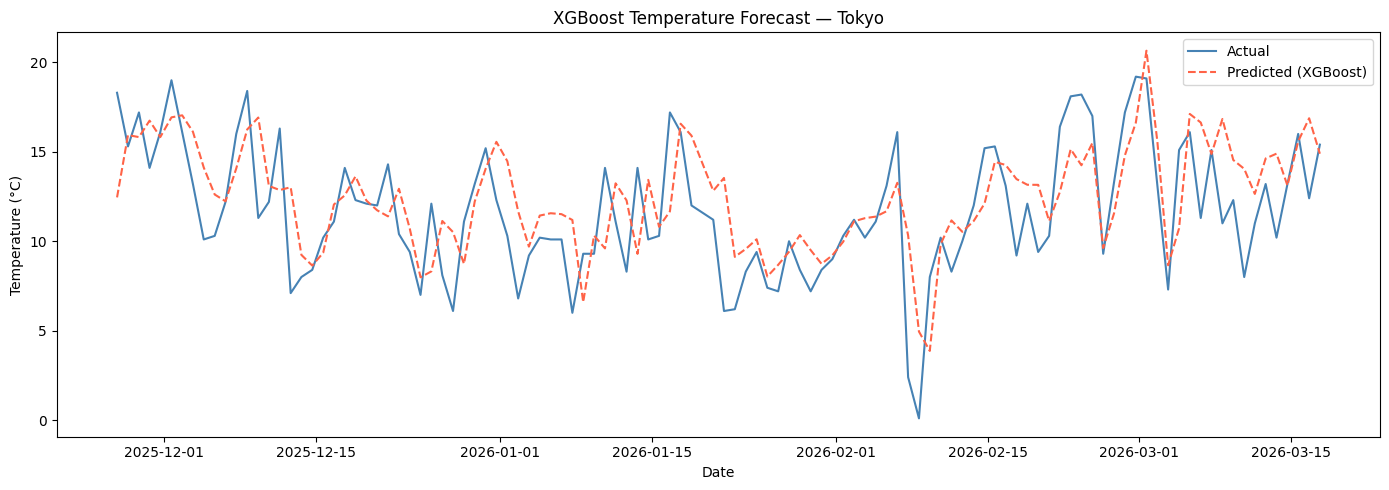

In [21]:
# VISUALIZE PREDICTIONS 
# plot single city to show temporal fit

city = 'Tokyo'   # CHANGE CITY
city_mask_test = test_feat['location_name'] == city

if city_mask_test.sum() > 0:
    city_test = test_feat[city_mask_test].copy()
    city_preds = xgb_final.predict(city_test[FEATURE_COLS])

    city_true_c = inverse_temp(city_test[TARGET].values)
    city_pred_c = inverse_temp(city_preds)
    dates = city_test['last_updated']

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, city_true_c, label='Actual', color='steelblue', linewidth=1.5)
    ax.plot(dates, city_pred_c, label='Predicted (XGBoost)', color='tomato',
            linewidth=1.5, linestyle='--')
    ax.set_title(f'XGBoost Temperature Forecast — {city}')
    ax.set_ylabel('Temperature (°C)')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"'{city}' not found in test set. Available sample cities:")
    print(test_feat['location_name'].unique()[:10])

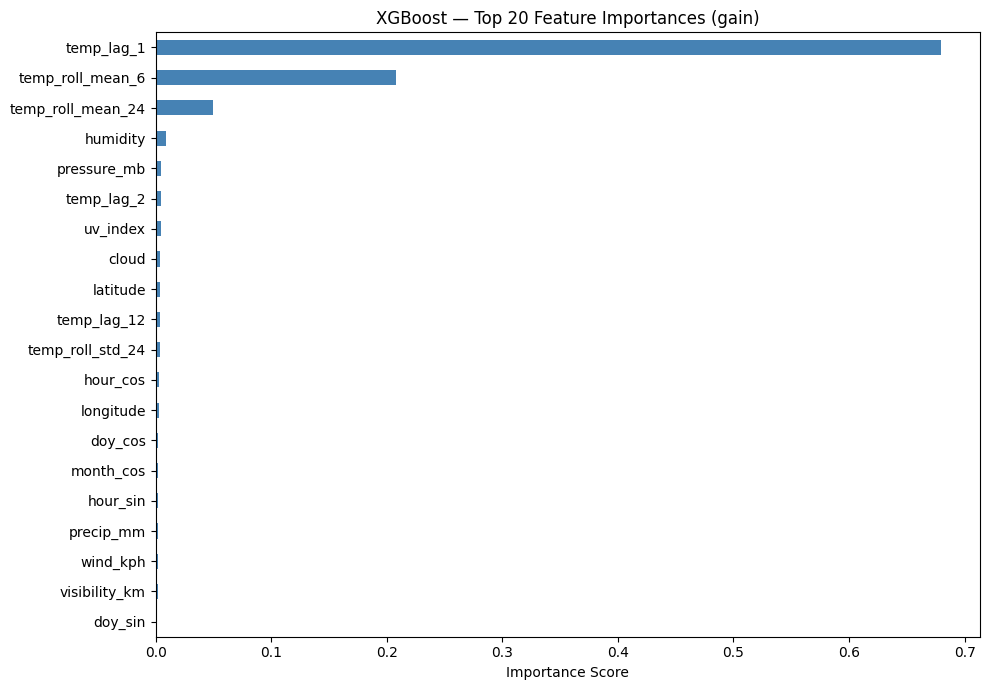


Top 10 features:
temp_lag_1           0.679374
temp_roll_mean_6     0.207862
temp_roll_mean_24    0.049372
humidity             0.008567
pressure_mb          0.004976
temp_lag_2           0.004758
uv_index             0.004310
cloud                0.003906
latitude             0.003774
temp_lag_12          0.003758


In [22]:
# FEATURE IMPORTANCE PLOT

importances = pd.Series(xgb_final.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importances.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('XGBoost — Top 20 Feature Importances (gain)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10).to_string())

### Use lastupdated feature for the time series analysis.

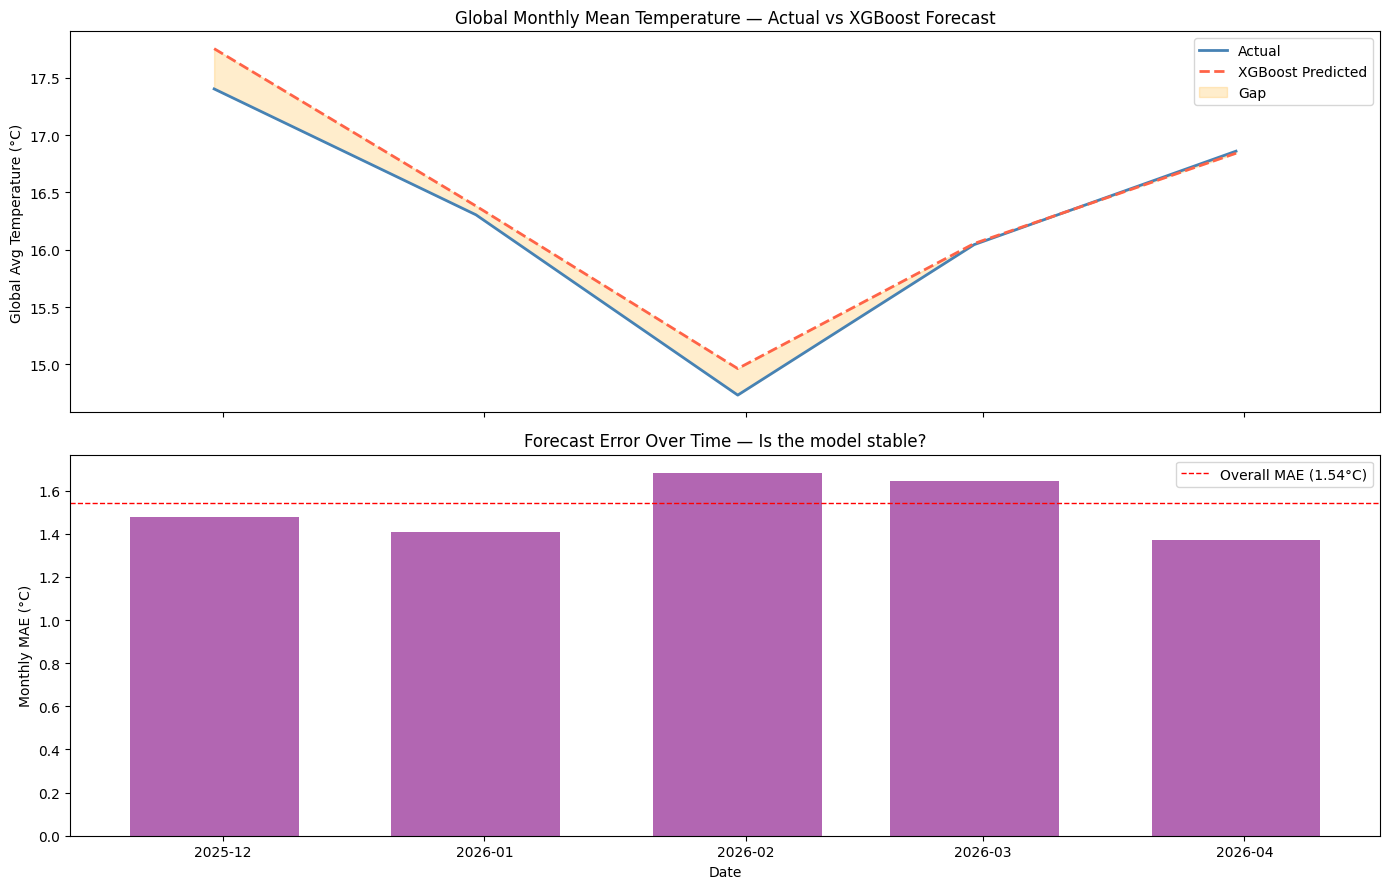

In [23]:
ts_df = test_feat[['last_updated', 'location_name', 'latitude', 'longitude']].copy()
ts_df['last_updated'] = pd.to_datetime(ts_df['last_updated'])
ts_df['y_true']       = y_true_celsius
ts_df['y_pred']       = y_pred_celsius
ts_df['residual']     = ts_df['y_true'] - ts_df['y_pred']
ts_df['abs_error']    = ts_df['residual'].abs()

# GLOBAL TEMP TREND PLOT 
monthly_ts = ts_df.set_index('last_updated').resample('ME').agg(
    true_mean  = ('y_true', 'mean'),
    pred_mean  = ('y_pred', 'mean'),
    mae_monthly= ('abs_error', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# actual vs predicted global mean temperature
axes[0].plot(monthly_ts['last_updated'], monthly_ts['true_mean'],
             color='steelblue', linewidth=2, label='Actual')
axes[0].plot(monthly_ts['last_updated'], monthly_ts['pred_mean'],
             color='tomato', linewidth=2, linestyle='--', label='XGBoost Predicted')
axes[0].fill_between(monthly_ts['last_updated'],
                     monthly_ts['true_mean'], monthly_ts['pred_mean'],
                     alpha=0.2, color='orange', label='Gap')
axes[0].set_ylabel('Global Avg Temperature (°C)')
axes[0].set_title('Global Monthly Mean Temperature — Actual vs XGBoost Forecast')
axes[0].legend()

# Panel 2: Monthly MAE over time (model reliability drift check)
axes[1].bar(monthly_ts['last_updated'], monthly_ts['mae_monthly'],
            color='purple', alpha=0.6, width=20)
axes[1].axhline(mae, color='red', linestyle='--', linewidth=1, label=f'Overall MAE ({mae:.2f}°C)')
axes[1].set_ylabel('Monthly MAE (°C)')
axes[1].set_title('Forecast Error Over Time — Is the model stable?')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()